# Part 1: Generating and Visualizing DCT Basis Images

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.fftpack import dct, idct

# 2D DCT
def dct2(image):
    return dct(
        dct(image, axis=0, norm='ortho'),
        axis=1,
        norm='ortho'
    )

# 2D Inverse DCT
def idct2(coefficients):
    return idct(
        idct(coefficients, axis=0, norm='ortho'),
        axis=1,
        norm='ortho'
    )

### Generate all 64 basis images:

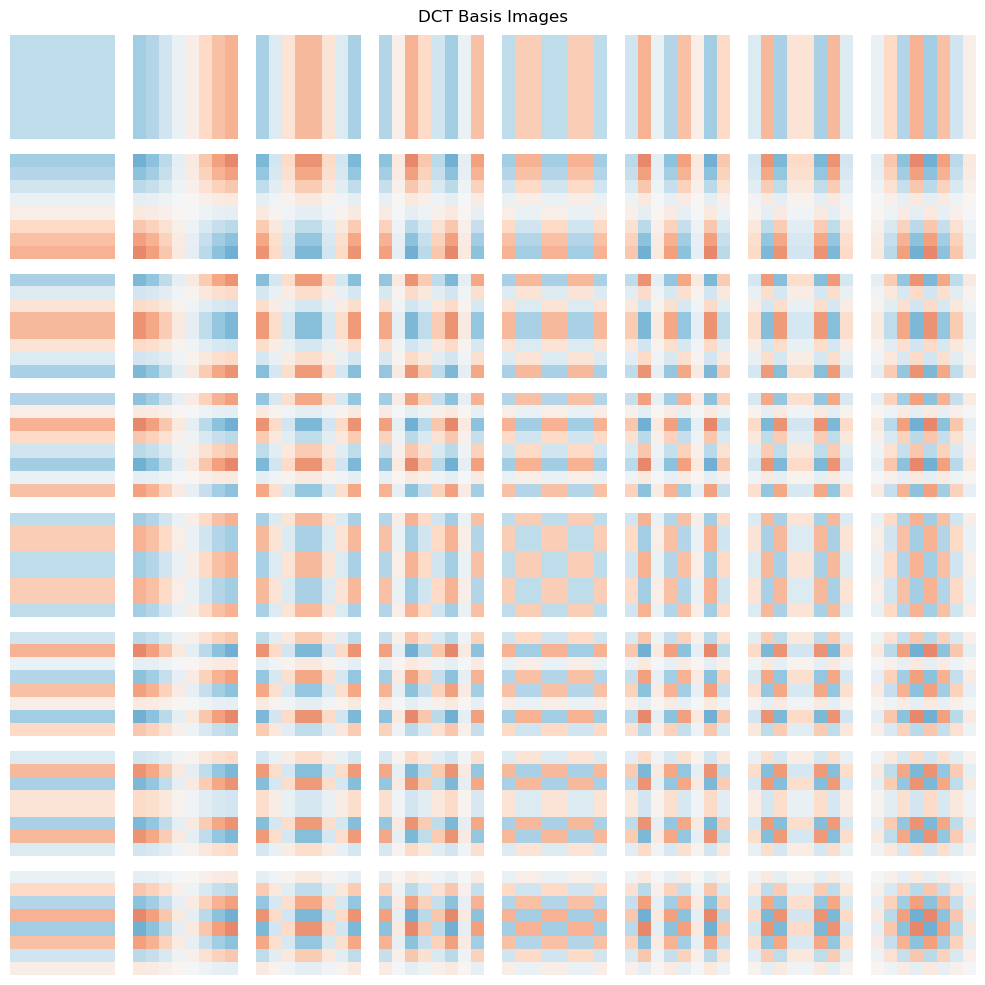

In [11]:
N = 8

fig, axes = plt.subplots(N, N, figsize=(10, 10))

for k1 in range(N):
    for k2 in range(N):

        # Create a frequency impulse
        F = np.zeros((N, N))
        F[k1, k2] = 1.0

        # Generate corresponding basis image
        basis = idct2(F)

        axes[k1, k2].imshow(
            basis,
            cmap='RdBu',
            vmin=-0.5,
            vmax=0.5
        )

        axes[k1, k2].axis('off')

plt.suptitle("DCT Basis Images")
plt.tight_layout()
plt.savefig('part1')
plt.show()

# Part 2: Applying DCT and Perfect Reconstruction

In [3]:
from skimage import data, transform
from sklearn.metrics import mean_squared_error

# Load sample image
img = data.camera()

# Resize image for faster computation
img = transform.resize(
    img,
    (256, 256),
    anti_aliasing=True
)

img = img.astype(np.float64)

# Compute DCT coefficients
F = dct2(img)

# Reconstruct image using inverse DCT
reconstructed = idct2(F)

# Calculate reconstruction error
mse = mean_squared_error(
    img.flatten(),
    reconstructed.flatten()
)

print("MSE =", mse)

MSE = 5.785160903650008e-32


# Part 3: Energy Compaction and Compression

In [5]:
# logarithmic magnitude spectrum
spectrum = np.log1p(np.abs(F))

### Keeping Only a Percentage of Coefficients

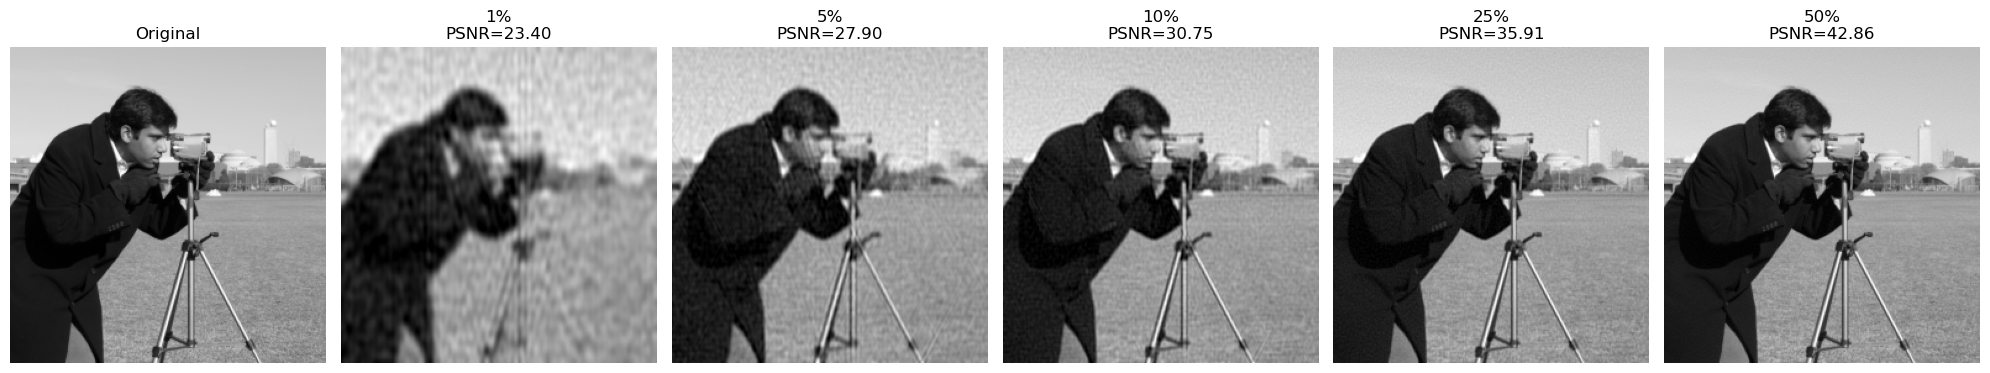

In [6]:
from skimage.metrics import peak_signal_noise_ratio

percentages = [1, 5, 10, 25, 50]
psnr_values = []

fig, axes = plt.subplots(1, 6, figsize=(20, 4))

# Show original image
axes[0].imshow(img, cmap='gray')
axes[0].set_title("Original")
axes[0].axis('off')

for idx, p in enumerate(percentages):

    # Magnitude of coefficients
    magnitude = np.abs(F)

    # Threshold corresponding to top p%
    threshold = np.percentile(
        magnitude,
        100 - p
    )

    # Keep only largest coefficients
    F_compressed = F.copy()
    F_compressed[magnitude < threshold] = 0

    # Reconstruct image
    rec = idct2(F_compressed)
    rec = np.clip(rec, 0, 1)

    # Compute PSNR
    psnr = peak_signal_noise_ratio(
        img,
        rec,
        data_range=1
    )

    psnr_values.append(psnr)

    axes[idx + 1].imshow(rec, cmap='gray')
    axes[idx + 1].set_title(
        f"{p}%\nPSNR={psnr:.2f}"
    )
    axes[idx + 1].axis('off')

plt.tight_layout()
# plt.savefig('part3')
plt.show()

# Part 4: Filtering in the Transform Domain

In [7]:
N = F.shape[0]

# Frequency coordinate grid
K1, K2 = np.meshgrid(
    np.arange(N),
    np.arange(N),
    indexing='ij'
)

# Distance from DC component
D = np.sqrt(K1**2 + K2**2)

r1 = N / 8
r2 = N / 4

# Low-pass masks
LP1 = (D <= r1).astype(float)
LP2 = (D <= r2).astype(float)

In [8]:
# Keep only low-frequency coefficients
img_lp1 = np.clip(
    idct2(F * LP1),
    0,
    1
)

img_lp2 = np.clip(
    idct2(F * LP2),
    0,
    1
)

In [9]:
# Remove low-frequency coefficients
HP = (D > r1).astype(float)

img_hp = idct2(F * HP)

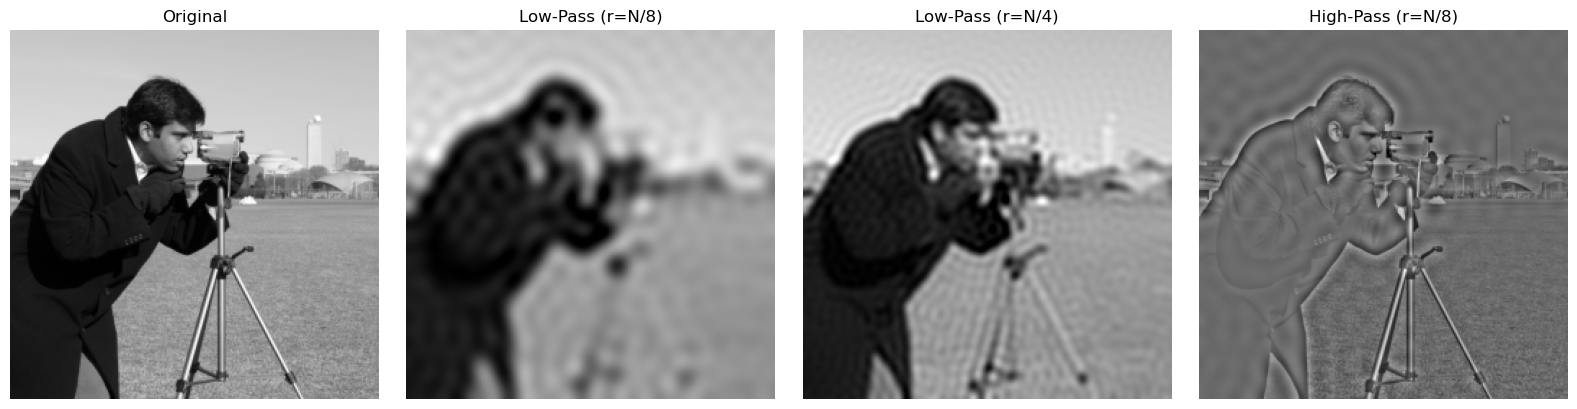

In [10]:
fig, ax = plt.subplots(1, 4, figsize=(16, 4))

ax[0].imshow(img, cmap='gray')
ax[0].set_title("Original")

ax[1].imshow(img_lp1, cmap='gray')
ax[1].set_title("Low-Pass (r=N/8)")

ax[2].imshow(img_lp2, cmap='gray')
ax[2].set_title("Low-Pass (r=N/4)")

ax[3].imshow(img_hp, cmap='gray')
ax[3].set_title("High-Pass (r=N/8)")

for a in ax:
    a.axis('off')

plt.tight_layout()
plt.savefig('part4')
plt.show()